In [2]:
import pandas as ps# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("Wholesale customers data.csv")


In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.tail()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [17]:
X = df[["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen" ]]

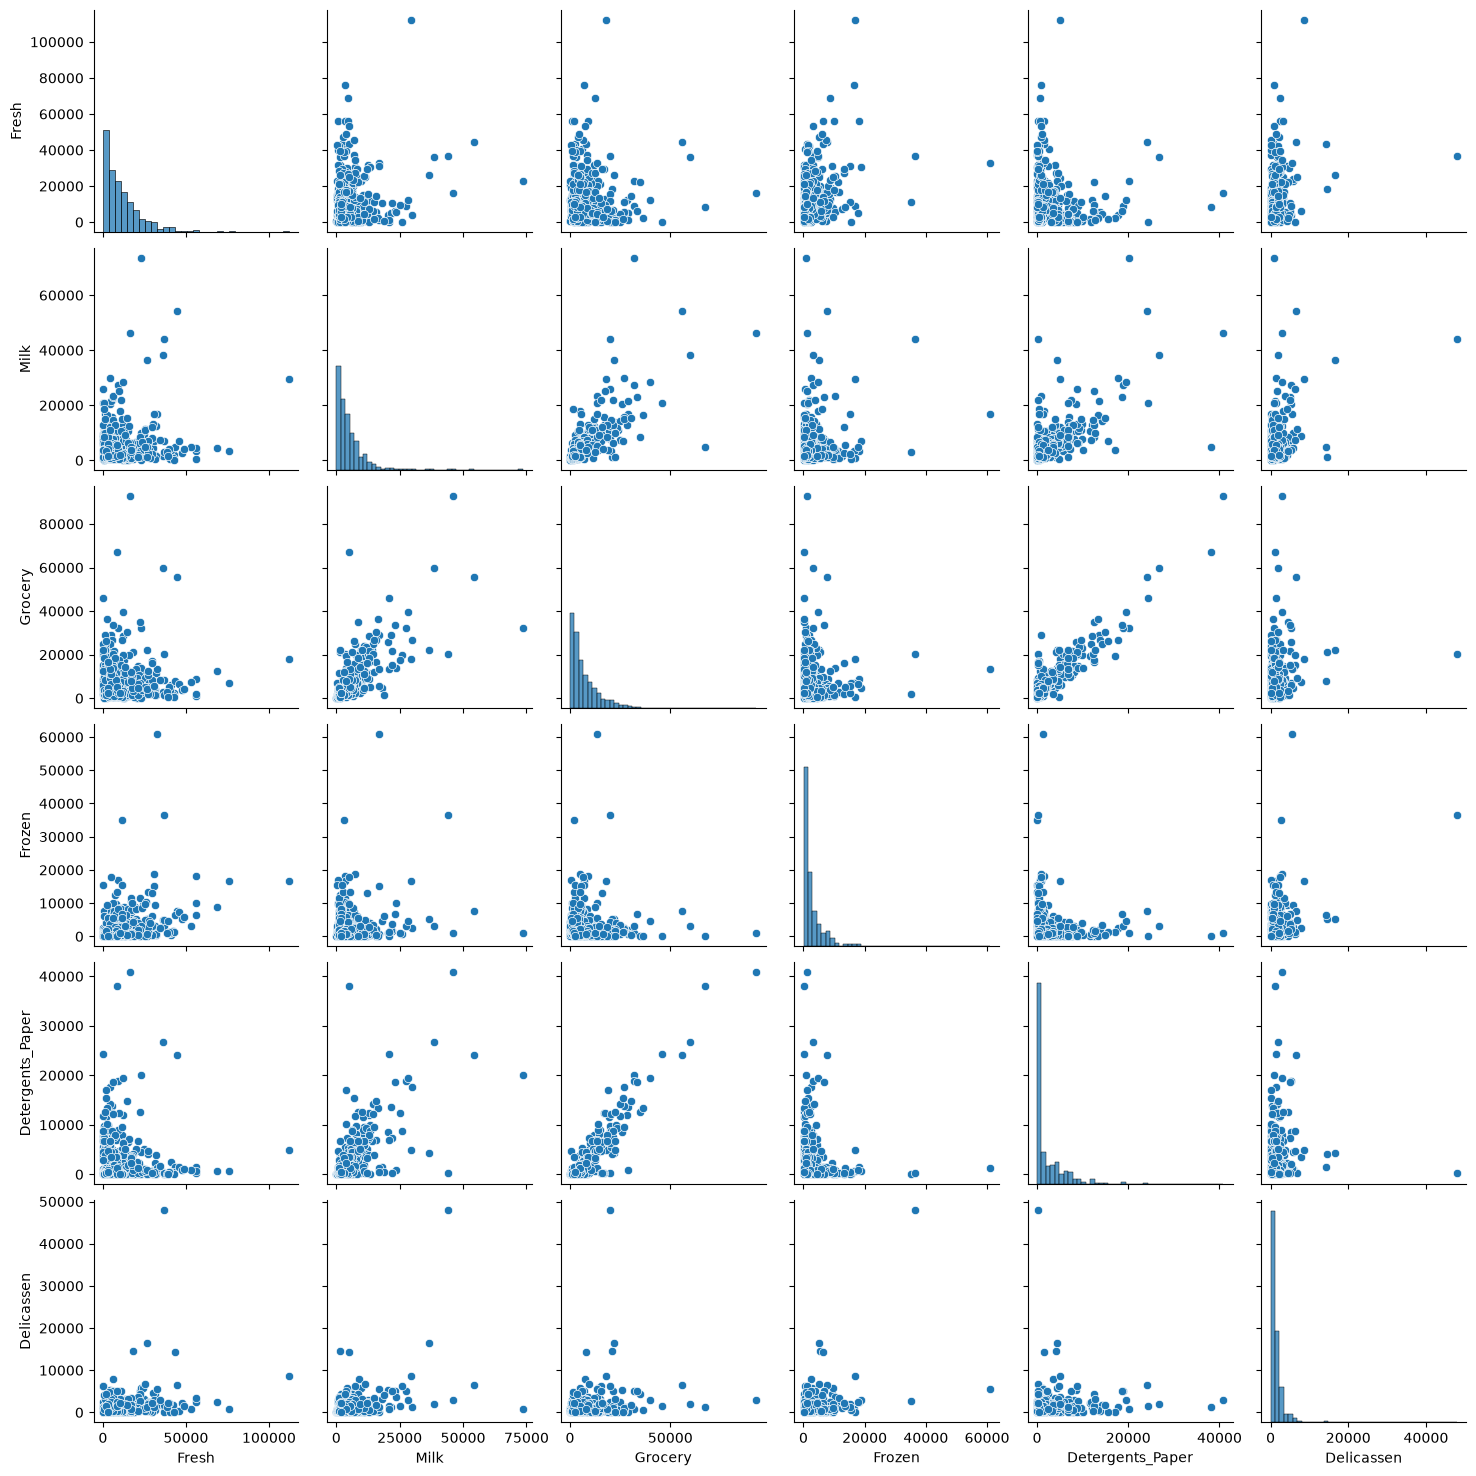

In [20]:
import seaborn as sns

sns.pairplot(
    df[[
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen"
    ]]
)

plt.show()

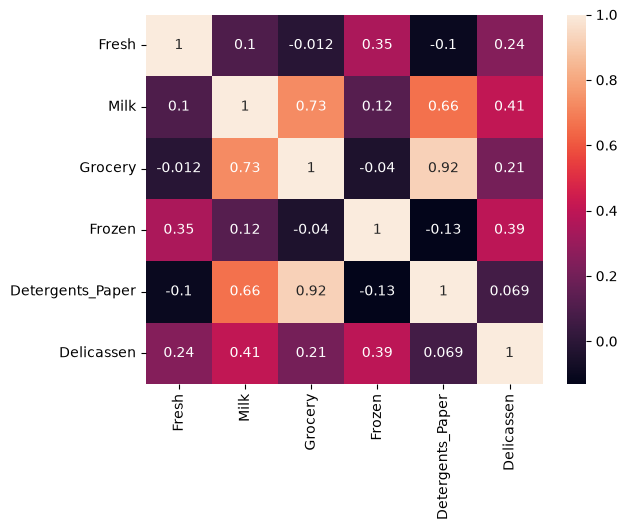

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(X.corr(), annot=True)
plt.show()

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

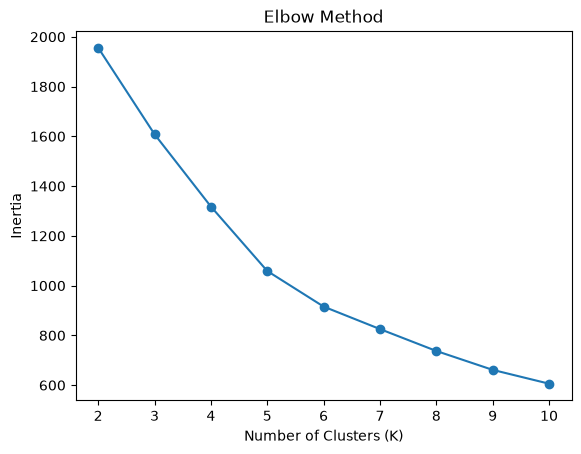

In [25]:
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [26]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.547
K=3, Silhouette Score=0.548
K=4, Silhouette Score=0.348
K=5, Silhouette Score=0.369
K=6, Silhouette Score=0.378
K=7, Silhouette Score=0.334
K=8, Silhouette Score=0.320
K=9, Silhouette Score=0.309
K=10, Silhouette Score=0.311


In [28]:
# ==========================================
# 7. CREATE K-MEANS MODEL
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [29]:
# ==========================================
# 8. TRAIN MODEL
# ==========================================

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 6)","[[-0.

In [30]:
# ==========================================
# 9. GET CLUSTERS
# ==========================================

clusters = kmeans.labels_

print(clusters)

[1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 2 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 2 1 1 1 1 1 0 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [31]:
# ==========================================
# 10. ADD CLUSTER TO DATAFRAME
# ==========================================

df["Cluster"] = clusters

df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1
5,2,3,9413,8259,5126,666,1795,1451,1
6,2,3,12126,3199,6975,480,3140,545,1
7,2,3,7579,4956,9426,1669,3321,2566,1
8,1,3,5963,3648,6192,425,1716,750,1
9,2,3,6006,11093,18881,1159,7425,2098,0


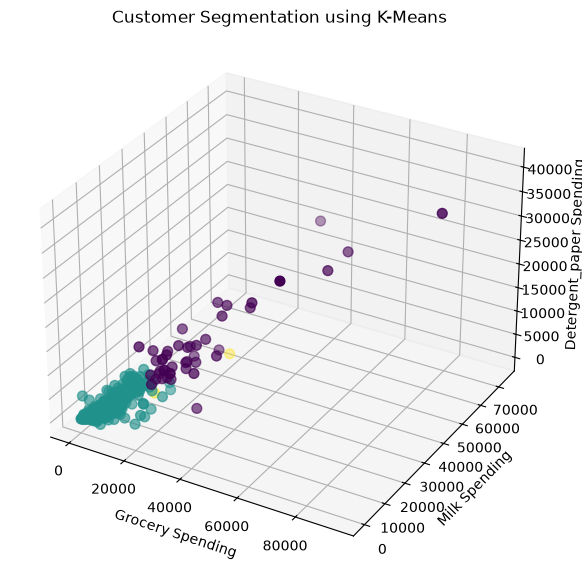

In [39]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# ==========================================
# 11. VISUALIZE CLUSTERS - 3D
# ==========================================

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Grocery"],
    df["Milk"],
    df["Detergents_Paper"],
    c=df["Cluster"],
    s=50
)

ax.set_xlabel("Grocery Spending")
ax.set_ylabel("Milk Spending")
ax.set_zlabel("Detergent_paper Spending")

ax.set_title("Customer Segmentation using K-Means")

plt.show()

In [33]:
cluster_summary = df.groupby("Cluster")[[
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]].mean()

cluster_summary

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


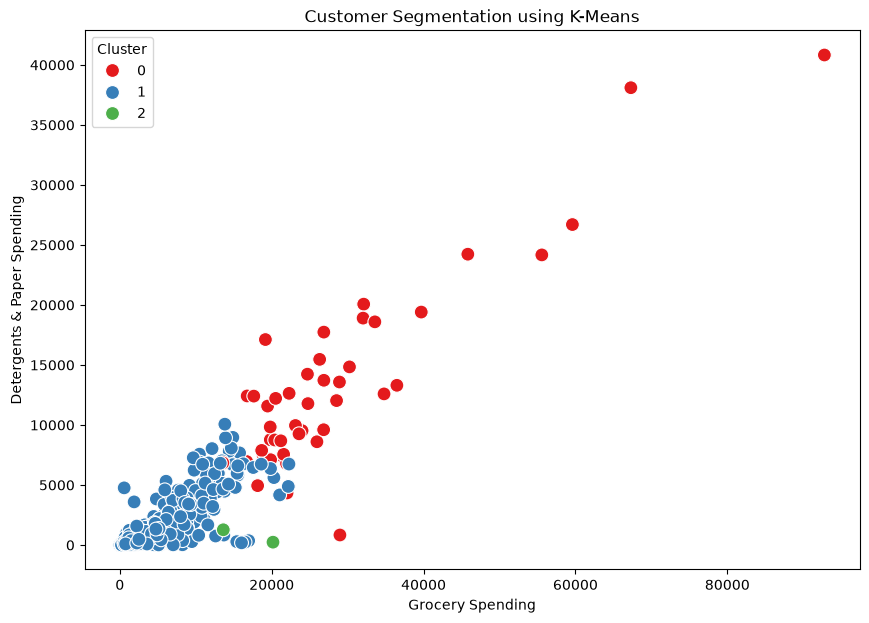

In [44]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Grocery",
    y="Detergents_Paper",
    hue="Cluster",
    palette="Set1",
    s=100
)




plt.title("Customer Segmentation using K-Means")
plt.xlabel("Grocery Spending")
plt.ylabel("Detergents & Paper Spending")

plt.show()

In [46]:
# ==========================================
# 12. CLUSTER CENTERS
# ==========================================

centers = kmeans.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[-1.23436296e-01  1.84348655e+00  2.18120855e+00 -1.81822945e-01
   2.19348095e+00  3.01512198e-01]
 [ 4.95654341e-03 -2.28048013e-01 -2.54553236e-01 -2.70676053e-02
  -2.48890139e-01 -8.01434183e-02]
 [ 1.80335587e+00  3.33298726e+00  9.42518505e-01  9.40980070e+00
  -4.46409015e-01  8.96415723e+00]]


In [47]:
# Convert cluster centers back to original scale

centers_original = scaler.inverse_transform(centers)

print(centers_original)

[[10440.93333333 19386.42222222 28656.08888889  2190.24444444
  13327.8         2374.2       ]
 [12062.91348601  4115.09923664  5534.96692112  2940.67684478
   1696.17048346  1299.11450382]
 [34782.         30367.         16898.         48701.5
    755.5        26776.        ]]


In [49]:
# ==========================================
# 13. CLUSTER CENTER TABLE
# ==========================================

centers_df = pd.DataFrame(
    centers_original,
    columns=[
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen"
    ]
)

print(centers_df)

          Fresh          Milk       Grocery        Frozen  Detergents_Paper  \
0  10440.933333  19386.422222  28656.088889   2190.244444      13327.800000   
1  12062.913486   4115.099237   5534.966921   2940.676845       1696.170483   
2  34782.000000  30367.000000  16898.000000  48701.500000        755.500000   

     Delicassen  
0   2374.200000  
1   1299.114504  
2  26776.000000  


In [50]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


In [55]:
df.sample(0)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster


In [57]:
df['Cluster'].unique()

array([1, 0, 2], dtype=int32)

In [58]:
cluster_map = {
    0: "High Annual Spending",
    1: "Low Annual Spending",
    2: "Medium Annual Spending"
}

df["Spending_Group"] = df["Cluster"].map(cluster_map)

In [59]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,Spending_Group
0,2,3,12669,9656,7561,214,2674,1338,1,Low Annual Spending
1,2,3,7057,9810,9568,1762,3293,1776,1,Low Annual Spending
2,2,3,6353,8808,7684,2405,3516,7844,1,Low Annual Spending
3,1,3,13265,1196,4221,6404,507,1788,1,Low Annual Spending
4,2,3,22615,5410,7198,3915,1777,5185,1,Low Annual Spending


In [60]:
df.sample(20)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,Spending_Group
168,1,3,5809,735,803,1393,79,429,1,Low Annual Spending
323,1,2,13360,944,11593,915,1679,573,1,Low Annual Spending
408,2,3,8257,3880,6407,1646,2730,344,1,Low Annual Spending
225,1,1,12680,3243,4157,660,761,786,1,Low Annual Spending
227,1,1,4042,2204,1563,2286,263,689,1,Low Annual Spending
65,2,3,85,20959,45828,36,24231,1423,0,High Annual Spending
430,1,3,3097,4230,16483,575,241,2080,1,Low Annual Spending
175,2,3,2343,7845,11874,52,4196,1697,1,Low Annual Spending
369,1,3,6211,337,683,1089,41,296,1,Low Annual Spending
159,2,3,355,7704,14682,398,8077,303,1,Low Annual Spending
